In [1]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import os

# Exploring USDA Disturbance Data for Region 8

This Python script performs data processing tasks on USDA disturbance data for Region 8. The script follows a series of steps to filter, manipulate, and save the data for further analysis. Here's a breakdown of what each step accomplishes:

1. **Loading CSV File**: The script begins by loading the USDA disturbance data from a CSV file located at `/Net/Groups/BGI/work_2/ForExD/USDA/tables/CONUS_Region8_dissolved.csv` into a Pandas DataFrame.

2. **Converting WKT Geometries**: The WKT (Well-Known Text) geometries in the DataFrame are converted into Shapely geometries. This step ensures that the spatial data can be processed and analyzed using Geopandas.

3. **Converting to GeoDataFrame**: The DataFrame is converted into a GeoDataFrame, enabling spatial operations and visualization.

4. **Filtering Data**: Disturbance records outside the timeframe of 2016 to 2020 are filtered out. Additionally, specific disturbance types such as 'other', 'multi_damage', 'other_abiotic', and 'other_biotic' are excluded from the analysis.

5. **Renaming Columns**: The column 'Unnamed: 0' is renamed to 'index_usda' for clarity and consistency.

6. **Exploding Multipolygons**: Multipolygon geometries are exploded into individual polygons. This step ensures that each polygon is treated as a separate entity for analysis.

7. **Saving Results**: The processed GeoDataFrame is saved as a CSV file named `region8_dca_id_filtered_usda_polygons.csv`. The file is saved in the directory `/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results`.

8. **Confirmation Message**: Finally, a confirmation message is printed, indicating that the results have been successfully saved to the specified location.

This script streamlines the data processing workflow, allowing researchers to efficiently analyze USDA disturbance data for Region 8.

In [6]:
# Step 1: Read the CSV file into a DataFrame
print("Step 1: Loading CSV file...")
input_file = "/Net/Groups/BGI/work_2/ForExD/USDA/tables/CONUS_Region8_dissolved.csv"
df = pd.read_csv(input_file)

# Step 2: Convert the WKT geometries to Shapely geometries
print("Step 2: Converting WKT geometries...")
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
print("Step 3: Converting DataFrame to GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Set the coordinate reference system (CRS) if it's not already set
gdf.set_crs(epsg=4326, inplace=True)

# Step 4: Filter for disturbances recorded between 2016 and 2020
print("Step 4: Filtering disturbances recorded between 2016 and 2020...")
gdf_timeframe = gdf[(gdf['SURVEY_YEAR'] > 2016) & (gdf['SURVEY_YEAR'] <= 2020)]

# Filter out specific disturbance types
excluded_types = ['other', 'multi_damage', 'other_abiotic', 'other_biotic']
rslt_df = gdf_timeframe[~gdf_timeframe['DCA_ID'].isin(excluded_types)].copy()

# Step 5: Rename the column 'Unnamed: 0' to 'index_usda'
print("Step 5: Rename columns for clarity and consistency")
rslt_df.rename(columns={'Unnamed: 0': 'index_usda'}, inplace=True)

# Step 6: Explode multipolygons into individual polygons
print("Step 6: Exploding multipolygons into individual polygons...")
exploded_df = rslt_df.explode(index_parts=True)

# Reset the index to ensure a clean index
exploded_df.reset_index(drop=True, inplace=True)

# Step 7: Generate new index_usda values
print("Step 7: Generating new index_usda values...")
exploded_df['index_usda'] = exploded_df.apply(lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1)

# Define the absolute path to the "results" folder
results_folder = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results"

# Define the output CSV file path
output_file = os.path.join(results_folder, "region8_dca_filtered_ids_usda_polygons.csv")

# Step 8: Save the exploded DataFrame to a CSV file in the results folder
print(f"Step 8: Saving results to: {output_file}...")
exploded_df.to_csv(output_file, index=False)

# Display the path of the saved CSV file
print(f"Results saved to: {output_file}")

Step 1: Loading CSV file...
Step 2: Converting WKT geometries...
Step 3: Converting DataFrame to GeoDataFrame...
Step 4: Filtering disturbances recorded between 2016 and 2020...
Step 5: Rename columns for clarity and consistency
Step 6: Exploding multipolygons into individual polygons...
Step 7: Generating new index_usda values...
Step 8: Saving results to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv...
Results saved to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv


In [10]:
rslt_df

,index_usda,DCA_ID,SURVEY_YEAR,geometry,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE
16,16,bark_beetle,2017,"MULTIPOLYGON (((-82.69315 29.16785, -82.69322 ...",8,Mortality,2,11003,1,No Data,shortleaf pine,-1.0
17,17,bark_beetle,2018,"MULTIPOLYGON (((-82.32171 29.30769, -82.32136 ...",8,Mortality,2,11003,1,Moderate (11-29%),shortleaf pine,110.0
18,18,bark_beetle,2019,"MULTIPOLYGON (((-94.16455 30.44747, -94.16436 ...",8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0
19,19,bark_beetle,2020,"MULTIPOLYGON (((-81.92146 29.79954, -81.92043 ...",8,Mortality,2,11030,1,Light (4-10%),loblolly pine,131.0
29,41,defoliators,2017,"MULTIPOLYGON (((-91.28137 29.73700, -91.27226 ...",8,Defoliation > 75% of leaves defoliated,14,12096,2,Severe (30-50%),baldcypress,221.0
30,42,defoliators,2018,"MULTIPOLYGON (((-91.27198 29.79836, -91.27385 ...",8,Defoliation > 75% of leaves defoliated,14,12096,2,Very Severe (>50%),baldcypress,221.0
31,43,defoliators,2019,"MULTIPOLYGON (((-91.32282 29.70653, -91.32997 ...",8,Defoliation > 75% of leaves defoliated,14,12096,2,Moderate (11-29%),loblolly pine,131.0
40,53,drought,2017,"MULTIPOLYGON (((-86.08884 33.17791, -86.08992 ...",8,Mortality,2,50003,4,Very Light (1-3%),All tree species,9998.0
41,54,drought,2018,"MULTIPOLYGON (((-92.96429 31.99252, -92.96351 ...",8,Mortality,2,50003,4,Very Severe (>50%),All tree species,9998.0
42,55,drought,2019,"POLYGON ((-95.17872 31.57849, -95.17968 31.578...",8,Mortality,2,50003,4,Moderate (11-29%),All tree species,9998.0


In [9]:
exploded_df

,index_usda,DCA_ID,SURVEY_YEAR,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,geometry
0,bark_beetle_2017_0,bark_beetle,2017,8,Mortality,2,11003,1,No Data,shortleaf pine,-1.0,"POLYGON ((-82.69315 29.16785, -82.69322 29.167..."
1,bark_beetle_2017_1,bark_beetle,2017,8,Mortality,2,11003,1,No Data,shortleaf pine,-1.0,"POLYGON ((-82.89726 29.37135, -82.89742 29.371..."
2,bark_beetle_2017_2,bark_beetle,2017,8,Mortality,2,11003,1,No Data,shortleaf pine,-1.0,"POLYGON ((-82.38086 29.66393, -82.38090 29.663..."
3,bark_beetle_2017_3,bark_beetle,2017,8,Mortality,2,11003,1,No Data,shortleaf pine,-1.0,"POLYGON ((-82.36094 29.66487, -82.36096 29.664..."
4,bark_beetle_2017_4,bark_beetle,2017,8,Mortality,2,11003,1,No Data,shortleaf pine,-1.0,"POLYGON ((-82.41875 29.67526, -82.41879 29.675..."
...,...,...,...,...,...,...,...,...,...,...,...,...
10606,wind_2019_10606,wind,2019,8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),No host tree,9997.0,"POLYGON ((-76.95135 34.98590, -76.94982 34.984..."
10607,wind_2019_10607,wind,2019,8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),No host tree,9997.0,"POLYGON ((-76.95057 34.97882, -76.95011 34.978..."
10608,wind_2019_10608,wind,2019,8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),No host tree,9997.0,"POLYGON ((-76.94165 34.97847, -76.94249 34.978..."
10609,wind_2019_10609,wind,2019,8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),No host tree,9997.0,"POLYGON ((-76.78273 34.79132, -76.78266 34.791..."


<Axes: >

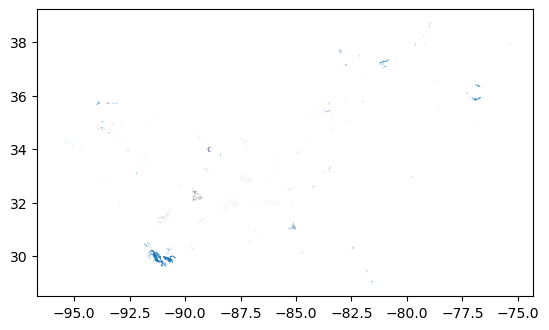

In [8]:
exploded_df.plot()